In [27]:
import pandas as pd
import os
from pathlib import Path

In [28]:
# Set the path to your logs directory
logs_path = "../lns_clean/logs/LNS/empty163248"

# Load the main CSV files
experiments_df = pd.read_csv(f"{logs_path}/experiments.csv")
lazy_iterations_df = pd.read_csv(f"{logs_path}/lazy_iterations.csv")
local_zones_df = pd.read_csv(f"{logs_path}/local_zones.csv")
makespan_attempts_df = pd.read_csv(f"{logs_path}/makespan_attempts.csv")
waiting_attempts_df = pd.read_csv(f"{logs_path}/waiting_attempts.csv")

# Display basic info about each DataFrame
print("=== EXPERIMENTS ===")
print(f"Shape: {experiments_df.shape}")
print(experiments_df.head())

print("\n=== MAKESPAN ATTEMPTS ===")
print(f"Shape: {makespan_attempts_df.shape}")
print(makespan_attempts_df.head())

print("\n=== LOCAL ZONES ===")
print(f"Shape: {local_zones_df.shape}")
print(local_zones_df.head())

print("\n=== WAITING ATTEMPTS ===")
print(f"Shape: {waiting_attempts_df.shape}")
print(waiting_attempts_df.head())

print("\n=== LAZY ITERATIONS ===")
print(f"Shape: {lazy_iterations_df.shape}")
print(lazy_iterations_df.head())

=== EXPERIMENTS ===
Shape: (921, 16)
                                       experiment_id  \
0  _home_max_Documents_PhD_MAPF_LNS_MAPF_LNS_SAT_...   
1  _home_max_Documents_PhD_MAPF_LNS_MAPF_LNS_SAT_...   
2  _home_max_Documents_PhD_MAPF_LNS_MAPF_LNS_SAT_...   
3  _home_max_Documents_PhD_MAPF_LNS_MAPF_LNS_SAT_...   
4  _home_max_Documents_PhD_MAPF_LNS_MAPF_LNS_SAT_...   

                                            map_path  \
0  /home/max/Documents/PhD/MAPF/LNS/MAPF_LNS_SAT/...   
1  /home/max/Documents/PhD/MAPF/LNS/MAPF_LNS_SAT/...   
2  /home/max/Documents/PhD/MAPF/LNS/MAPF_LNS_SAT/...   
3  /home/max/Documents/PhD/MAPF/LNS/MAPF_LNS_SAT/...   
4  /home/max/Documents/PhD/MAPF/LNS/MAPF_LNS_SAT/...   

                                       scenario_path  num_agents  \
0  /home/max/Documents/PhD/MAPF/LNS/MAPF_LNS_SAT/...          10   
1  /home/max/Documents/PhD/MAPF/LNS/MAPF_LNS_SAT/...          10   
2  /home/max/Documents/PhD/MAPF/LNS/MAPF_LNS_SAT/...          10   
3  /home/max/Docu

In [29]:
import re

def extract_map_info(map_path):
    """Extract map information from various map path formats"""
    # Extract the map name from the path
    map_name = map_path.split('/')[-1].replace('.map', '')
    
    # Try to extract dimensions for empty maps (empty-16-16, empty-32-32, etc.)
    empty_match = re.search(r'empty-(\d+)-(\d+)', map_name)
    if empty_match:
        return {
            'map_type': 'empty',
            'map_size': f"{empty_match.group(1)}x{empty_match.group(2)}",
            'map_name': map_name
        }
    
    # For other map types, just return the map name
    return {
        'map_type': 'other',
        'map_size': 'unknown',
        'map_name': map_name
    }

# Apply the function to extract map information
experiments_df['map_info'] = experiments_df['map_path'].apply(extract_map_info)

# Create separate columns for easier analysis
experiments_df['map_type'] = experiments_df['map_info'].apply(lambda x: x['map_type'])
experiments_df['map_size'] = experiments_df['map_info'].apply(lambda x: x['map_size'])
experiments_df['map_name'] = experiments_df['map_info'].apply(lambda x: x['map_name'])

# Now group by map type and size
print("=== DATA GROUPED BY MAP TYPE ===")
map_groups = experiments_df.groupby(['map_type', 'map_size'])

for (map_type, map_size), group in map_groups:
    print(f"\n--- MAP: {map_type} {map_size} ---")
    print(f"Number of experiments: {len(group)}")
    print(f"Number of agents: {group['num_agents'].unique()}")
    print(f"Success rate: {group['solved'].mean():.2%}")
    print(f"Average runtime: {group['total_runtime_ms'].mean():.2f} ms")
    print(f"Average makespan: {group['makespan_success'].mean():.2f}")

=== DATA GROUPED BY MAP TYPE ===

--- MAP: empty 16x16 ---
Number of experiments: 220
Number of agents: [ 10  20  50 100]
Success rate: 100.00%
Average runtime: 4931.74 ms
Average makespan: 20.54

--- MAP: empty 32x32 ---
Number of experiments: 301
Number of agents: [ 10  20  50 100]
Success rate: 100.00%
Average runtime: 49.81 ms
Average makespan: 42.93

--- MAP: empty 48x48 ---
Number of experiments: 400
Number of agents: [ 10  20  50 100]
Success rate: 100.00%
Average runtime: 195.26 ms
Average makespan: 67.08


In [30]:
import pandas as pd
import os
from pathlib import Path

# Load LNS experiments from all directories
lns_directories = ['Berlin', 'Paris', 'Rooms', 'Warehouse2-2', 'empty163248']
lns_experiments = []

for directory in lns_directories:
    try:
        df = pd.read_csv(f"../lns_clean/logs/LNS/{directory}/experiments.csv")
        df['solver'] = 'LNS'
        df['source_directory'] = directory
        lns_experiments.append(df)
        print(f"LNS - Loaded {len(df)} experiments from {directory}")
    except FileNotFoundError:
        print(f"LNS - Directory {directory} not found")

# Load WholeSolve experiments from all directories
wholesolve_directories = ['Berlin', 'Paris', 'Rooms', 'Warehouse2-2', 'empty163248']
wholesolve_experiments = []

for directory in wholesolve_directories:
    try:
        df = pd.read_csv(f"../lns_clean/logs/WholeSolve/{directory}/experiments.csv")
        df['solver'] = 'WholeSolve'
        df['source_directory'] = directory
        wholesolve_experiments.append(df)
        print(f"WholeSolve - Loaded {len(df)} experiments from {directory}")
    except FileNotFoundError:
        print(f"WholeSolve - Directory {directory} not found")

# Combine all experiments
all_lns = pd.concat(lns_experiments, ignore_index=True) if lns_experiments else pd.DataFrame()
all_wholesolve = pd.concat(wholesolve_experiments, ignore_index=True) if wholesolve_experiments else pd.DataFrame()

print(f"\n=== TOTAL EXPERIMENTS ===")
print(f"LNS: {len(all_lns)} experiments")
print(f"WholeSolve: {len(all_wholesolve)} experiments")

# Compare by directory
print(f"\n=== EXPERIMENTS BY DIRECTORY ===")
if len(all_lns) > 0:
    print("LNS by directory:")
    lns_by_dir = all_lns.groupby('source_directory').size()
    for dir_name, count in lns_by_dir.items():
        print(f"  {dir_name}: {count} experiments")

if len(all_wholesolve) > 0:
    print("\nWholeSolve by directory:")
    wholesolve_by_dir = all_wholesolve.groupby('source_directory').size()
    for dir_name, count in wholesolve_by_dir.items():
        print(f"  {dir_name}: {count} experiments")

LNS - Loaded 312 experiments from Berlin
LNS - Loaded 315 experiments from Paris
LNS - Loaded 281 experiments from Rooms
LNS - Loaded 795 experiments from Warehouse2-2
LNS - Loaded 921 experiments from empty163248
WholeSolve - Loaded 3 experiments from Berlin
WholeSolve - Loaded 1 experiments from Paris
WholeSolve - Loaded 47 experiments from Rooms
WholeSolve - Directory Warehouse2-2 not found
WholeSolve - Loaded 246 experiments from empty163248

=== TOTAL EXPERIMENTS ===
LNS: 2624 experiments
WholeSolve: 297 experiments

=== EXPERIMENTS BY DIRECTORY ===
LNS by directory:
  Berlin: 312 experiments
  Paris: 315 experiments
  Rooms: 281 experiments
  Warehouse2-2: 795 experiments
  empty163248: 921 experiments

WholeSolve by directory:
  Berlin: 3 experiments
  Paris: 1 experiments
  Rooms: 47 experiments
  empty163248: 246 experiments


In [36]:
def load_experiment_data(directory, solver_type):
    """Load all experiment data for a directory and solver type"""
    base_path = f"../lns_clean/logs/{solver_type}/{directory}"
    
    try:
        # Load main experiments
        experiments = pd.read_csv(f"{base_path}/experiments.csv")
        experiments['solver'] = solver_type
        experiments['source_directory'] = directory
        
        # Load additional data files (these might be empty for immediate solves)
        try:
            makespan_attempts = pd.read_csv(f"{base_path}/makespan_attempts.csv")
        except (FileNotFoundError, pd.errors.EmptyDataError):
            makespan_attempts = pd.DataFrame()
            
        try:
            local_zones = pd.read_csv(f"{base_path}/local_zones.csv")
        except (FileNotFoundError, pd.errors.EmptyDataError):
            local_zones = pd.DataFrame()
            
        try:
            waiting_attempts = pd.read_csv(f"{base_path}/waiting_attempts.csv")
        except (FileNotFoundError, pd.errors.EmptyDataError):
            waiting_attempts = pd.DataFrame()
            
        try:
            lazy_iterations = pd.read_csv(f"{base_path}/lazy_iterations.csv")
        except (FileNotFoundError, pd.errors.EmptyDataError):
            lazy_iterations = pd.DataFrame()
        
        # Identify immediate solves: experiments with all metrics = 0
        immediate_solves = experiments[
            (experiments['total_cnf_clauses'] == 0) &
            (experiments['total_cnf_variables'] == 0) &
            (experiments['total_mdd_build_ms'] == 0) &
            (experiments['total_cnf_build_ms'] == 0) &
            (experiments['total_lazy_wall_ms'] == 0) &
            (experiments['total_lazy_solver_wall_ms'] == 0) &
            (experiments['total_lazy_solver_reported_ms'] == 0)
        ]
        
        # Get experiments that appear in additional CSV files (these definitely had LNS activity)
        experiments_with_activity = set()
        if len(makespan_attempts) > 0:
            experiments_with_activity.update(makespan_attempts['experiment_id'].unique())
        if len(local_zones) > 0:
            experiments_with_activity.update(local_zones['experiment_id'].unique())
        if len(waiting_attempts) > 0:
            experiments_with_activity.update(waiting_attempts['experiment_id'].unique())
        if len(lazy_iterations) > 0:
            experiments_with_activity.update(lazy_iterations['experiment_id'].unique())
        
        # Filter out immediate solves
        filtered_experiments = experiments[
            ~experiments['experiment_id'].isin(immediate_solves['experiment_id'])
        ]
        
        print(f"{solver_type} - {directory}:")
        print(f"  Total experiments: {len(experiments)}")
        print(f"  Immediate solves: {len(immediate_solves)}")
        print(f"  Experiments with LNS activity: {len(experiments_with_activity)}")
        print(f"  Filtered experiments (excluding immediate solves): {len(filtered_experiments)}")
        
        return filtered_experiments, immediate_solves
        
    except FileNotFoundError as e:
        print(f"Could not load data for {solver_type}/{directory}: {e}")
        return pd.DataFrame(), pd.DataFrame()

In [37]:
LNS: 2624 experiments
WholeSolve: 297 experiments

SyntaxError: invalid syntax (1697872049.py, line 1)

In [39]:
# Load and filter data for both solvers
directories = ['Berlin', 'Paris', 'Rooms', 'Warehouse2-2', 'empty163248']

lns_filtered = []
lns_immediate = []
wholesolve_filtered = []
wholesolve_immediate = []

for directory in directories:
    # Load LNS data
    lns_exp, lns_imm = load_experiment_data(directory, 'LNS')
    if len(lns_exp) > 0:
        lns_filtered.append(lns_exp)
    if len(lns_imm) > 0:
        lns_immediate.append(lns_imm)
    
    # Load WholeSolve data
    ws_exp, ws_imm = load_experiment_data(directory, 'WholeSolve')
    if len(ws_exp) > 0:
        wholesolve_filtered.append(ws_exp)
    if len(ws_imm) > 0:
        wholesolve_immediate.append(ws_imm)

# Combine filtered data
lns_filtered_combined = pd.concat(lns_filtered, ignore_index=True) if lns_filtered else pd.DataFrame()
wholesolve_filtered_combined = pd.concat(wholesolve_filtered, ignore_index=True) if wholesolve_filtered else pd.DataFrame()

print(f"\n=== FILTERED EXPERIMENTS (EXCLUDING IMMEDIATE SOLVES) ===")
print(f"LNS with LNS activity: {len(lns_filtered_combined)} experiments")
print(f"WholeSolve with LNS activity: {len(wholesolve_filtered_combined)} experiments")

# Show breakdown by directory for filtered data
if len(lns_filtered_combined) > 0:
    print(f"\nLNS filtered by directory:")
    for dir_name, count in lns_filtered_combined.groupby('source_directory').size().items():
        print(f"  {dir_name}: {count} experiments")

if len(wholesolve_filtered_combined) > 0:
    print(f"\nWholeSolve filtered by directory:")
    for dir_name, count in wholesolve_filtered_combined.groupby('source_directory').size().items():
        print(f"  {dir_name}: {count} experiments")

LNS - Berlin:
  Total experiments: 312
  Immediate solves: 91
  Experiments with LNS activity: 313
  Filtered experiments (excluding immediate solves): 221
WholeSolve - Berlin:
  Total experiments: 3
  Immediate solves: 3
  Experiments with LNS activity: 3
  Filtered experiments (excluding immediate solves): 0
LNS - Paris:
  Total experiments: 315
  Immediate solves: 90
  Experiments with LNS activity: 316
  Filtered experiments (excluding immediate solves): 225
WholeSolve - Paris:
  Total experiments: 1
  Immediate solves: 1
  Experiments with LNS activity: 1
  Filtered experiments (excluding immediate solves): 0
LNS - Rooms:
  Total experiments: 281
  Immediate solves: 12
  Experiments with LNS activity: 294
  Filtered experiments (excluding immediate solves): 269
WholeSolve - Rooms:
  Total experiments: 47
  Immediate solves: 3
  Experiments with LNS activity: 47
  Filtered experiments (excluding immediate solves): 44
LNS - Warehouse2-2:
  Total experiments: 795
  Immediate solves: 

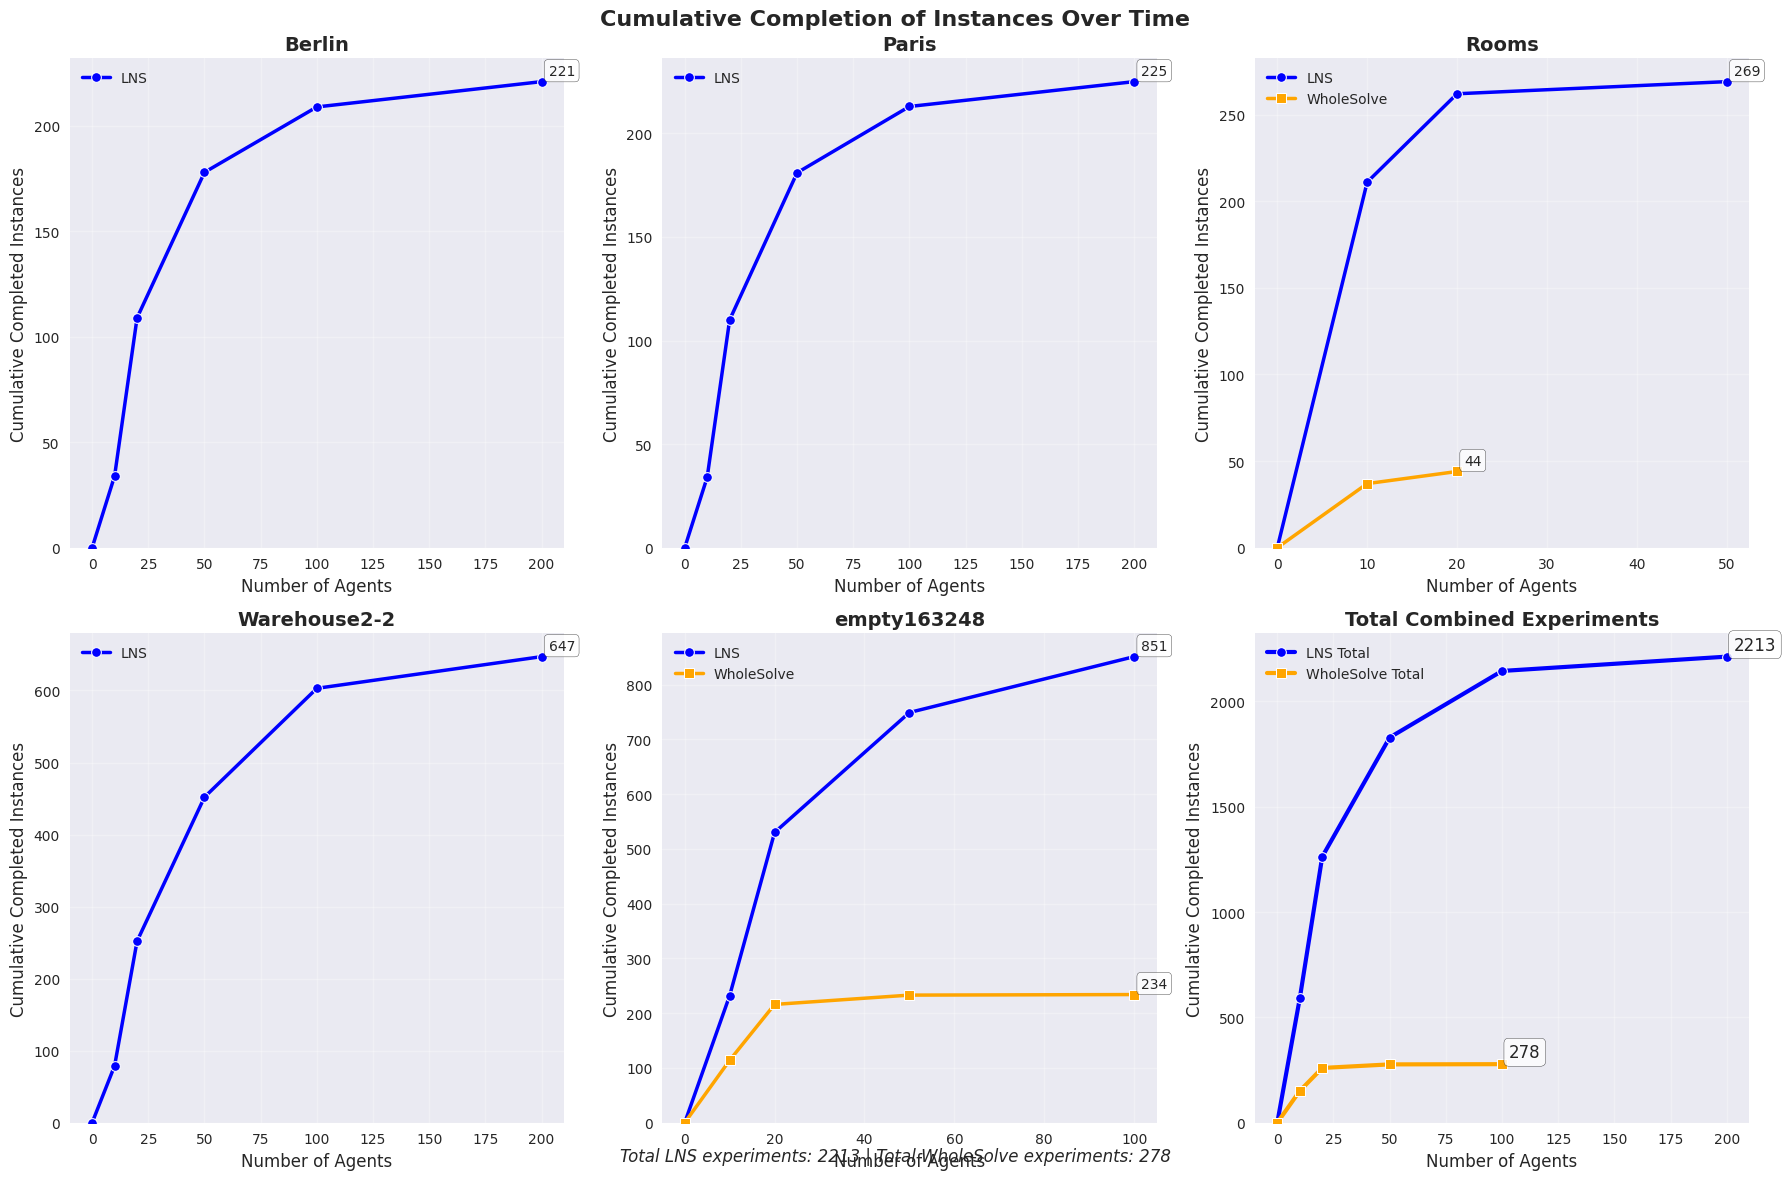

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set up the plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Create a figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Cumulative Completion of Instances Over Time', fontsize=16, fontweight='bold')

# Flatten axes for easier indexing
axes = axes.flatten()

# Plot for each directory
directories = ['Berlin', 'Paris', 'Rooms', 'Warehouse2-2', 'empty163248']

for i, directory in enumerate(directories):
    ax = axes[i]
    
    # Get data for this directory
    lns_data = lns_filtered_combined[lns_filtered_combined['source_directory'] == directory]
    ws_data = wholesolve_filtered_combined[wholesolve_filtered_combined['source_directory'] == directory]
    
    if len(lns_data) > 0 or len(ws_data) > 0:
        # Create cumulative completion data starting from 0
        lns_counts = lns_data.groupby('num_agents').size()
        ws_counts = ws_data.groupby('num_agents').size()
        
        # Create cumulative data starting from 0
        lns_cumulative = pd.Series([0] + lns_counts.cumsum().tolist(), 
                                 index=[0] + lns_counts.index.tolist())
        ws_cumulative = pd.Series([0] + ws_counts.cumsum().tolist(), 
                                index=[0] + ws_counts.index.tolist())
        
        # Plot LNS data in blue
        if len(lns_data) > 0:
            sns.lineplot(data=lns_cumulative, ax=ax, label='LNS', linewidth=2.5, marker='o', color='blue')
        
        # Plot WholeSolve data in orange
        if len(ws_data) > 0:
            sns.lineplot(data=ws_cumulative, ax=ax, label='WholeSolve', linewidth=2.5, marker='s', color='orange')
        
        ax.set_title(f'{directory}', fontsize=14, fontweight='bold')
        ax.set_xlabel('Number of Agents', fontsize=12)
        ax.set_ylabel('Cumulative Completed Instances', fontsize=12)
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Set y-axis to start from 0
        ax.set_ylim(bottom=0)
        
        # Add value annotations on the lines
        for line in ax.get_lines():
            x_data = line.get_xdata()
            y_data = line.get_ydata()
            if len(x_data) > 0:
                # Annotate the last point
                ax.annotate(f'{int(y_data[-1])}', 
                           xy=(x_data[-1], y_data[-1]), 
                           xytext=(5, 5), 
                           textcoords='offset points',
                           fontsize=10,
                           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    else:
        ax.text(0.5, 0.5, 'No data available', 
                transform=ax.transAxes, ha='center', va='center', fontsize=12)
        ax.set_title(f'{directory}', fontsize=14, fontweight='bold')

# Plot total combined experiments in the last subplot
ax_total = axes[5]

# Combine all LNS data starting from 0
lns_counts_total = lns_filtered_combined.groupby('num_agents').size()
ws_counts_total = wholesolve_filtered_combined.groupby('num_agents').size()

# Create cumulative data starting from 0
lns_total = pd.Series([0] + lns_counts_total.cumsum().tolist(), 
                     index=[0] + lns_counts_total.index.tolist())
ws_total = pd.Series([0] + ws_counts_total.cumsum().tolist(), 
                    index=[0] + ws_counts_total.index.tolist())

# Plot total LNS data in blue
if len(lns_total) > 0:
    sns.lineplot(data=lns_total, ax=ax_total, label='LNS Total', linewidth=3, marker='o', color='blue')

# Plot total WholeSolve data in orange
if len(ws_total) > 0:
    sns.lineplot(data=ws_total, ax=ax_total, label='WholeSolve Total', linewidth=3, marker='s', color='orange')

ax_total.set_title('Total Combined Experiments', fontsize=14, fontweight='bold')
ax_total.set_xlabel('Number of Agents', fontsize=12)
ax_total.set_ylabel('Cumulative Completed Instances', fontsize=12)
ax_total.legend()
ax_total.grid(True, alpha=0.3)
ax_total.set_ylim(bottom=0)

# Add value annotations on the total lines
for line in ax_total.get_lines():
    x_data = line.get_xdata()
    y_data = line.get_ydata()
    if len(x_data) > 0:
        # Annotate the last point
        ax_total.annotate(f'{int(y_data[-1])}', 
                         xy=(x_data[-1], y_data[-1]), 
                         xytext=(5, 5), 
                         textcoords='offset points',
                         fontsize=12,
                         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Adjust layout to prevent overlap
plt.tight_layout()

# Add overall statistics as text
total_lns = len(lns_filtered_combined)
total_ws = len(wholesolve_filtered_combined)

fig.text(0.5, 0.02, f'Total LNS experiments: {total_lns} | Total WholeSolve experiments: {total_ws}', 
         ha='center', fontsize=12, style='italic')

plt.show()

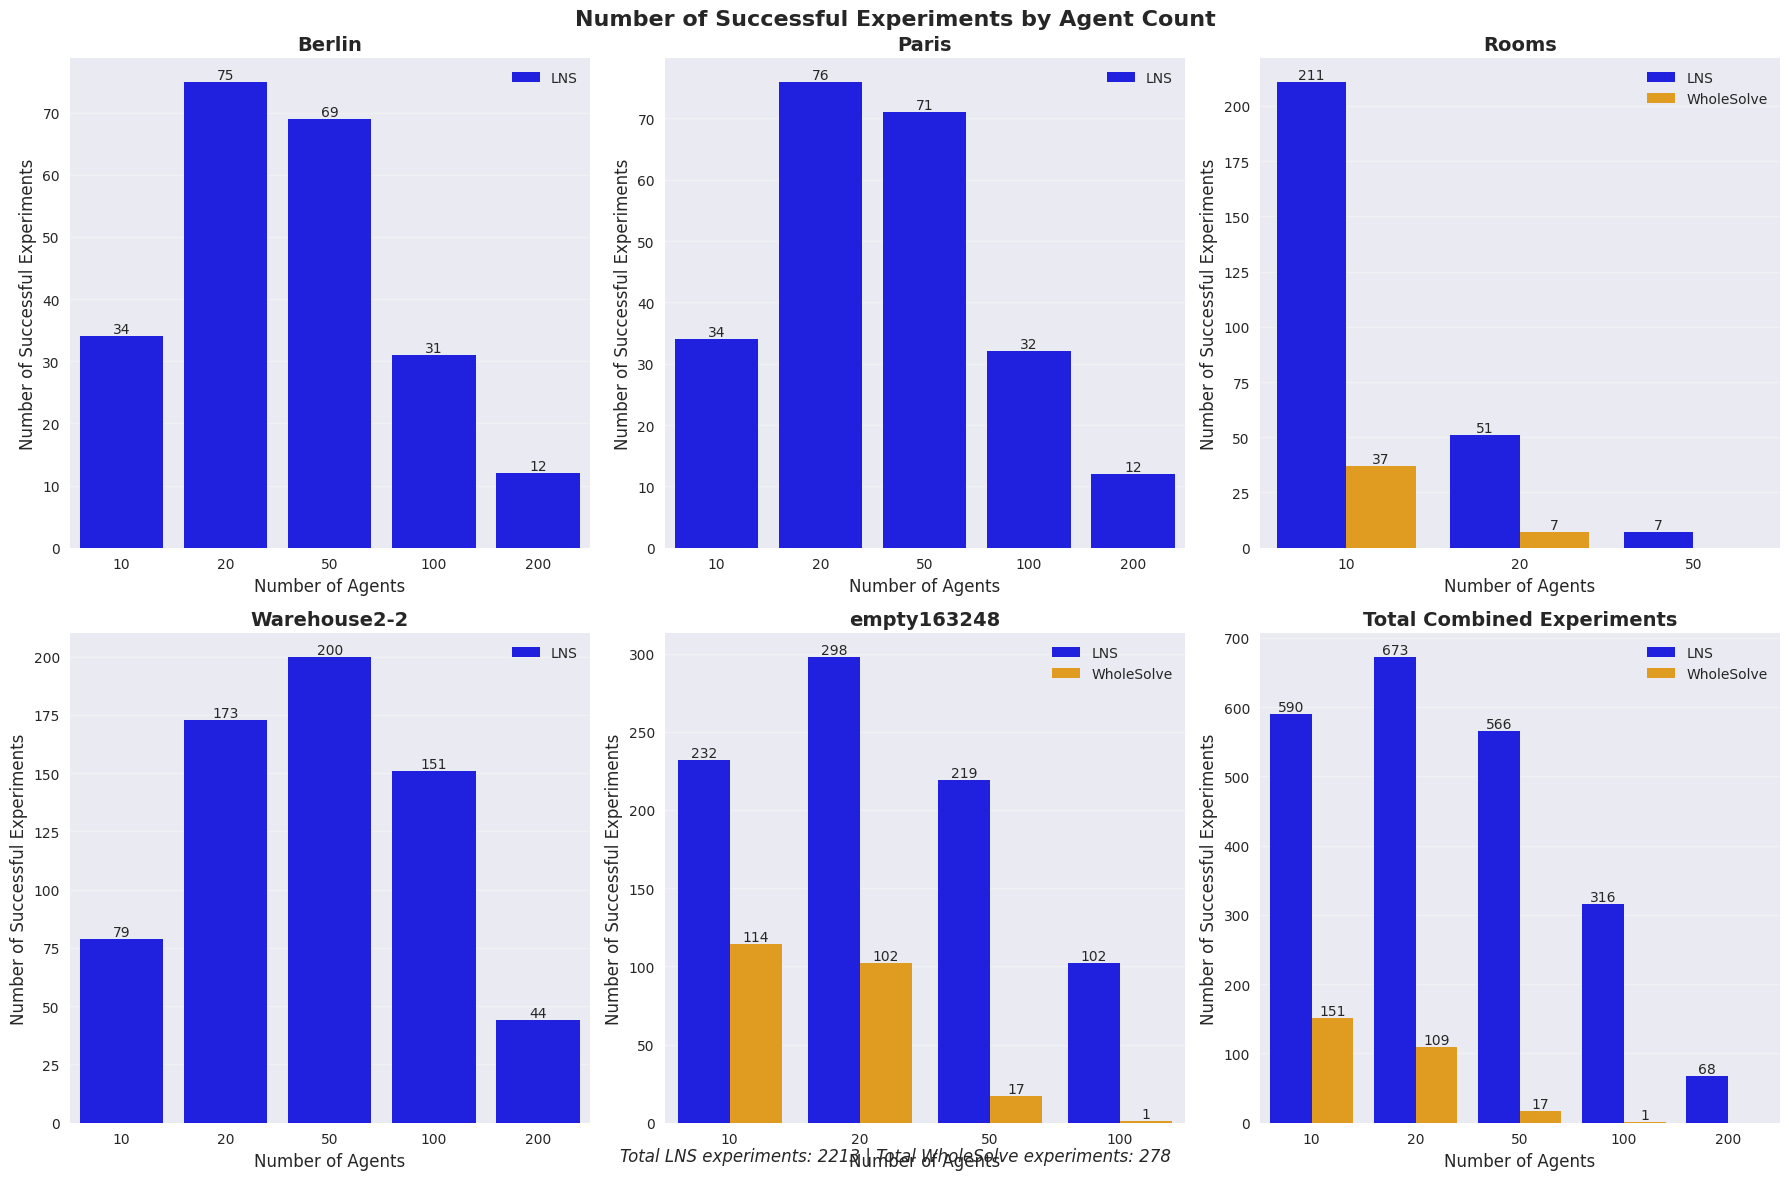

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set up the plotting style
plt.style.use('seaborn-v0_8')

# Create a figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Number of Successful Experiments by Agent Count', fontsize=16, fontweight='bold')

# Flatten axes for easier indexing
axes = axes.flatten()

# Plot for each directory
directories = ['Berlin', 'Paris', 'Rooms', 'Warehouse2-2', 'empty163248']

for i, directory in enumerate(directories):
    ax = axes[i]
    
    # Get data for this directory
    lns_data = lns_filtered_combined[lns_filtered_combined['source_directory'] == directory]
    ws_data = wholesolve_filtered_combined[wholesolve_filtered_combined['source_directory'] == directory]
    
    if len(lns_data) > 0 or len(ws_data) > 0:
        # Count experiments by agent count
        lns_counts = lns_data.groupby('num_agents').size()
        ws_counts = ws_data.groupby('num_agents').size()
        
        # Create a combined DataFrame for plotting
        plot_data = []
        
        # Add LNS data
        for agents, count in lns_counts.items():
            plot_data.append({'num_agents': agents, 'count': count, 'solver': 'LNS'})
        
        # Add WholeSolve data
        for agents, count in ws_counts.items():
            plot_data.append({'num_agents': agents, 'count': count, 'solver': 'WholeSolve'})
        
        if plot_data:
            df_plot = pd.DataFrame(plot_data)
            
            # Create grouped bar chart
            sns.barplot(data=df_plot, x='num_agents', y='count', hue='solver', ax=ax,
                       palette={'LNS': 'blue', 'WholeSolve': 'orange'})
            
            ax.set_title(f'{directory}', fontsize=14, fontweight='bold')
            ax.set_xlabel('Number of Agents', fontsize=12)
            ax.set_ylabel('Number of Successful Experiments', fontsize=12)
            ax.legend()
            ax.grid(True, alpha=0.3, axis='y')
            
            # Add value labels on top of bars
            for container in ax.containers:
                ax.bar_label(container, fontsize=10)
    else:
        ax.text(0.5, 0.5, 'No data available', 
                transform=ax.transAxes, ha='center', va='center', fontsize=12)
        ax.set_title(f'{directory}', fontsize=14, fontweight='bold')

# Plot total combined experiments in the last subplot
ax_total = axes[5]

# Combine all data
lns_counts_total = lns_filtered_combined.groupby('num_agents').size()
ws_counts_total = wholesolve_filtered_combined.groupby('num_agents').size()

# Create combined DataFrame for total
total_plot_data = []

# Add LNS data
for agents, count in lns_counts_total.items():
    total_plot_data.append({'num_agents': agents, 'count': count, 'solver': 'LNS'})

# Add WholeSolve data
for agents, count in ws_counts_total.items():
    total_plot_data.append({'num_agents': agents, 'count': count, 'solver': 'WholeSolve'})

if total_plot_data:
    df_total = pd.DataFrame(total_plot_data)
    
    # Create grouped bar chart for total
    sns.barplot(data=df_total, x='num_agents', y='count', hue='solver', ax=ax_total,
                palette={'LNS': 'blue', 'WholeSolve': 'orange'})
    
    ax_total.set_title('Total Combined Experiments', fontsize=14, fontweight='bold')
    ax_total.set_xlabel('Number of Agents', fontsize=12)
    ax_total.set_ylabel('Number of Successful Experiments', fontsize=12)
    ax_total.legend()
    ax_total.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on top of bars
    for container in ax_total.containers:
        ax_total.bar_label(container, fontsize=10)

# Adjust layout to prevent overlap
plt.tight_layout()

# Add overall statistics as text
total_lns = len(lns_filtered_combined)
total_ws = len(wholesolve_filtered_combined)

fig.text(0.5, 0.02, f'Total LNS experiments: {total_lns} | Total WholeSolve experiments: {total_ws}', 
         ha='center', fontsize=12, style='italic')

plt.show()

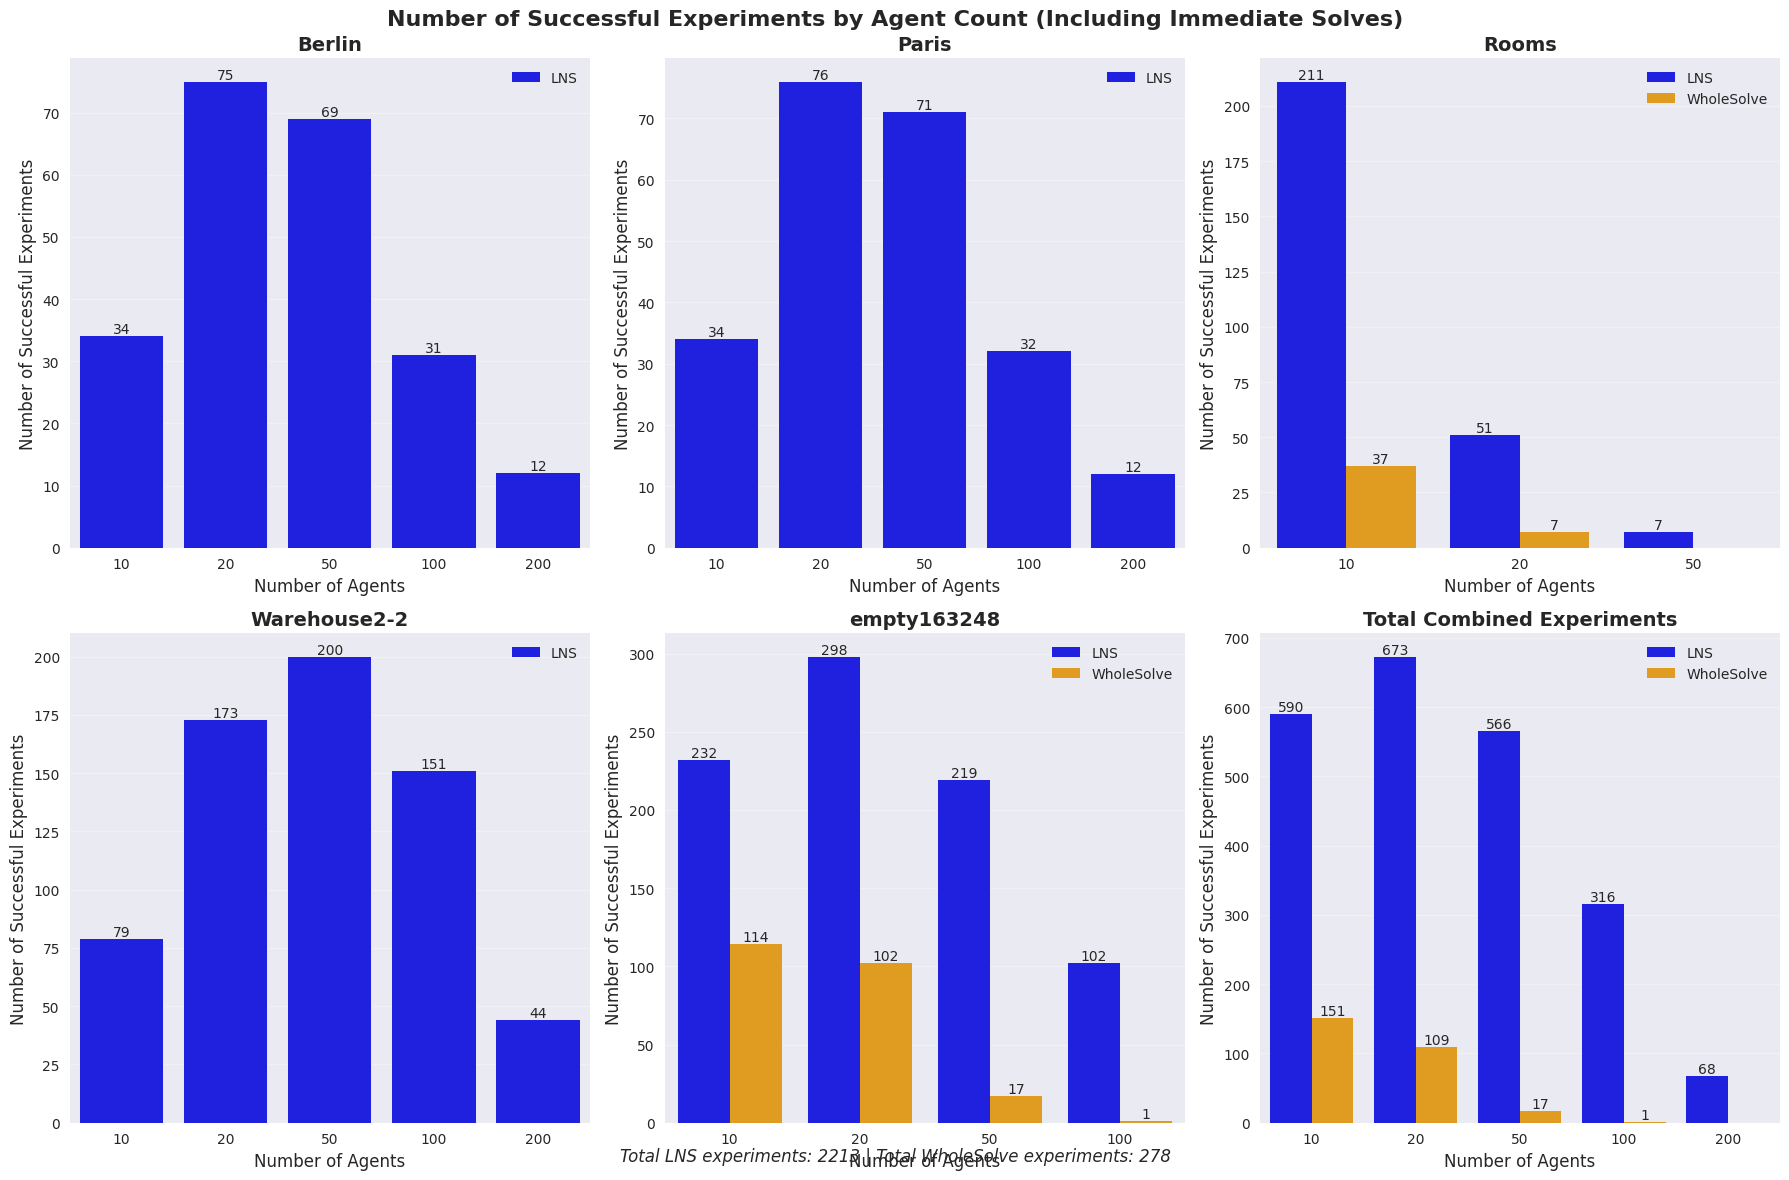

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set up the plotting style
plt.style.use('seaborn-v0_8')

# Create a figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Number of Successful Experiments by Agent Count (Including Immediate Solves)', fontsize=16, fontweight='bold')

# Flatten axes for easier indexing
axes = axes.flatten()

# Plot for each directory
directories = ['Berlin', 'Paris', 'Rooms', 'Warehouse2-2', 'empty163248']

for i, directory in enumerate(directories):
    ax = axes[i]
    
    # Get data for this directory
    lns_data = lns_filtered_combined[lns_filtered_combined['source_directory'] == directory]
    ws_data = wholesolve_filtered_combined[wholesolve_filtered_combined['source_directory'] == directory]
    
    if len(lns_data) > 0 or len(ws_data) > 0:
        # Count experiments by agent count
        lns_counts = lns_data.groupby('num_agents').size()
        ws_counts = ws_data.groupby('num_agents').size()
        
        # Create a combined DataFrame for plotting
        plot_data = []
        
        # Add LNS data
        for agents, count in lns_counts.items():
            plot_data.append({'num_agents': agents, 'count': count, 'solver': 'LNS'})
        
        # Add WholeSolve data
        for agents, count in ws_counts.items():
            plot_data.append({'num_agents': agents, 'count': count, 'solver': 'WholeSolve'})
        
        if plot_data:
            df_plot = pd.DataFrame(plot_data)
            
            # Create grouped bar chart
            sns.barplot(data=df_plot, x='num_agents', y='count', hue='solver', ax=ax,
                       palette={'LNS': 'blue', 'WholeSolve': 'orange'})
            
            # Add immediate solves as semi-transparent overlay
            # Get immediate solves counts from your previous analysis
            # You'll need to replace these with your actual immediate solves DataFrames
            # For now, let's create them from the original data
            
            # Get all experiments (including immediate solves) for this directory
            all_lns_data = lns_filtered_combined[lns_filtered_combined['source_directory'] == directory]
            all_ws_data = wholesolve_filtered_combined[wholesolve_filtered_combined['source_directory'] == directory]
            
            # Calculate immediate solves (experiments with all metrics = 0)
            immediate_lns = all_lns_data[
                (all_lns_data['total_cnf_clauses'] == 0) &
                (all_lns_data['total_cnf_variables'] == 0) &
                (all_lns_data['total_mdd_build_ms'] == 0) &
                (all_lns_data['total_cnf_build_ms'] == 0) &
                (all_lns_data['total_lazy_wall_ms'] == 0) &
                (all_lns_data['total_lazy_solver_wall_ms'] == 0) &
                (all_lns_data['total_lazy_solver_reported_ms'] == 0)
            ]
            
            immediate_ws = all_ws_data[
                (all_ws_data['total_cnf_clauses'] == 0) &
                (all_ws_data['total_cnf_variables'] == 0) &
                (all_ws_data['total_mdd_build_ms'] == 0) &
                (all_ws_data['total_cnf_build_ms'] == 0) &
                (all_ws_data['total_lazy_wall_ms'] == 0) &
                (all_ws_data['total_lazy_solver_wall_ms'] == 0) &
                (all_ws_data['total_lazy_solver_reported_ms'] == 0)
            ]
            
            # Get immediate solves counts
            immediate_lns_counts = immediate_lns.groupby('num_agents').size()
            immediate_ws_counts = immediate_ws.groupby('num_agents').size()
            
            # Add immediate solves bars on top
            for agents, count in immediate_lns_counts.items():
                ax.bar(agents, count, bottom=lns_counts.get(agents, 0), 
                      color='lightblue', alpha=0.6, label='LNS Immediate' if agents == list(immediate_lns_counts.index)[0] else "")
            
            for agents, count in immediate_ws_counts.items():
                ax.bar(agents, count, bottom=ws_counts.get(agents, 0), 
                      color='lightcoral', alpha=0.6, label='WS Immediate' if agents == list(immediate_ws_counts.index)[0] else "")
            
            ax.set_title(f'{directory}', fontsize=14, fontweight='bold')
            ax.set_xlabel('Number of Agents', fontsize=12)
            ax.set_ylabel('Number of Successful Experiments', fontsize=12)
            ax.legend()
            ax.grid(True, alpha=0.3, axis='y')
            
            # Add value labels on top of bars
            for container in ax.containers:
                ax.bar_label(container, fontsize=10)
    else:
        ax.text(0.5, 0.5, 'No data available', 
                transform=ax.transAxes, ha='center', va='center', fontsize=12)
        ax.set_title(f'{directory}', fontsize=14, fontweight='bold')

# Plot total combined experiments in the last subplot
ax_total = axes[5]

# Combine all data
lns_counts_total = lns_filtered_combined.groupby('num_agents').size()
ws_counts_total = wholesolve_filtered_combined.groupby('num_agents').size()

# Create combined DataFrame for total
total_plot_data = []

# Add LNS data
for agents, count in lns_counts_total.items():
    total_plot_data.append({'num_agents': agents, 'count': count, 'solver': 'LNS'})

# Add WholeSolve data
for agents, count in ws_counts_total.items():
    total_plot_data.append({'num_agents': agents, 'count': count, 'solver': 'WholeSolve'})

if total_plot_data:
    df_total = pd.DataFrame(total_plot_data)
    
    # Create grouped bar chart for total
    sns.barplot(data=df_total, x='num_agents', y='count', hue='solver', ax=ax_total,
                palette={'LNS': 'blue', 'WholeSolve': 'orange'})
    
    # Add immediate solves overlay for total
    immediate_lns_total = lns_filtered_combined[
        (lns_filtered_combined['total_cnf_clauses'] == 0) &
        (lns_filtered_combined['total_cnf_variables'] == 0) &
        (lns_filtered_combined['total_mdd_build_ms'] == 0) &
        (lns_filtered_combined['total_cnf_build_ms'] == 0) &
        (lns_filtered_combined['total_lazy_wall_ms'] == 0) &
        (lns_filtered_combined['total_lazy_solver_wall_ms'] == 0) &
        (lns_filtered_combined['total_lazy_solver_reported_ms'] == 0)
    ].groupby('num_agents').size()
    
    immediate_ws_total = wholesolve_filtered_combined[
        (wholesolve_filtered_combined['total_cnf_clauses'] == 0) &
        (wholesolve_filtered_combined['total_cnf_variables'] == 0) &
        (wholesolve_filtered_combined['total_mdd_build_ms'] == 0) &
        (wholesolve_filtered_combined['total_cnf_build_ms'] == 0) &
        (wholesolve_filtered_combined['total_lazy_wall_ms'] == 0) &
        (wholesolve_filtered_combined['total_lazy_solver_wall_ms'] == 0) &
        (wholesolve_filtered_combined['total_lazy_solver_reported_ms'] == 0)
    ].groupby('num_agents').size()
    
    for agents, count in immediate_lns_total.items():
        ax_total.bar(agents, count, bottom=lns_counts_total.get(agents, 0), 
                    color='lightblue', alpha=0.6, label='LNS Immediate' if agents == list(immediate_lns_total.index)[0] else "")
    
    for agents, count in immediate_ws_total.items():
        ax_total.bar(agents, count, bottom=ws_counts_total.get(agents, 0), 
                    color='lightcoral', alpha=0.6, label='WS Immediate' if agents == list(immediate_ws_total.index)[0] else "")
    
    ax_total.set_title('Total Combined Experiments', fontsize=14, fontweight='bold')
    ax_total.set_xlabel('Number of Agents', fontsize=12)
    ax_total.set_ylabel('Number of Successful Experiments', fontsize=12)
    ax_total.legend()
    ax_total.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on top of bars
    for container in ax_total.containers:
        ax_total.bar_label(container, fontsize=10)

# Adjust layout to prevent overlap
plt.tight_layout()

# Add overall statistics as text
total_lns = len(lns_filtered_combined)
total_ws = len(wholesolve_filtered_combined)

fig.text(0.5, 0.02, f'Total LNS experiments: {total_lns} | Total WholeSolve experiments: {total_ws}', 
         ha='center', fontsize=12, style='italic')

plt.show()